In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import seaborn as sns
sns.set(style="white")
import matplotlib as mpl

In [2]:
sys.path.append('..')

In [3]:
def coverage_age(p,e):
    return (1 +((1-e)*((1/p) -1)))**-1

In [4]:
def error_coverage_age(p,e):
    var = (1-e)/((e*(p-1) + 1)**2)
    return np.sqrt(var)

# Calculating $S_0$: first method

- Using ignored data as vaccinated
- Using stratified population, grouping since it is our only option now

We will do this by:
- Calculating $P(V_i|S_i)$ with its error
- Propagating to get $c_i$ with its error
- Propagating to get $S_0$ with its error

In [5]:
df_mun = pd.read_csv('../Data/analyzed/age_vaccine_municipalities.csv')

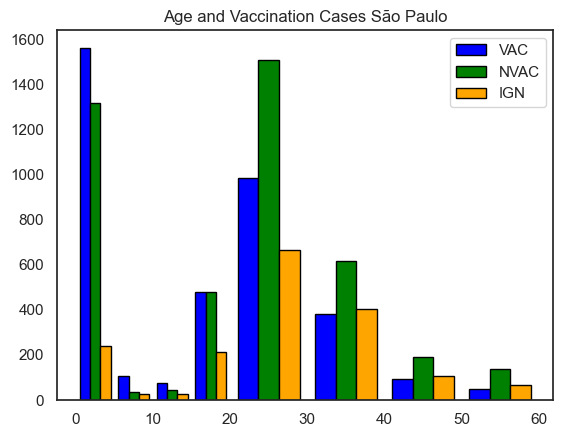

Considering ignored are vaccinated
6.343962633906609 1.2524321964778404
EXCLUDING IGNORED FROM SAMPLE
[0.92125466 0.96217105 0.93851133 0.90923269 0.87715783 0.87650306
 0.85528263 0.82278481]
9.80882033887125 1.8398723637736885


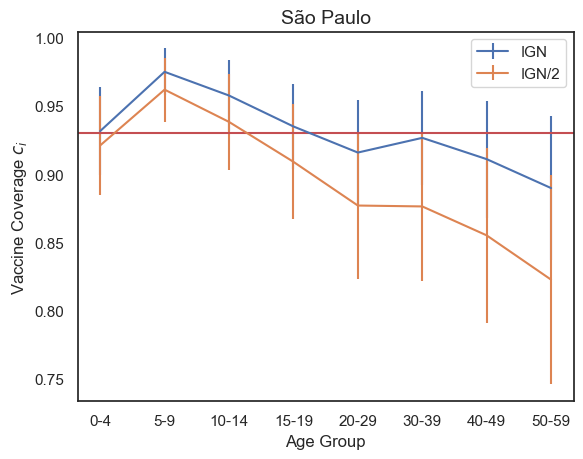

12396372


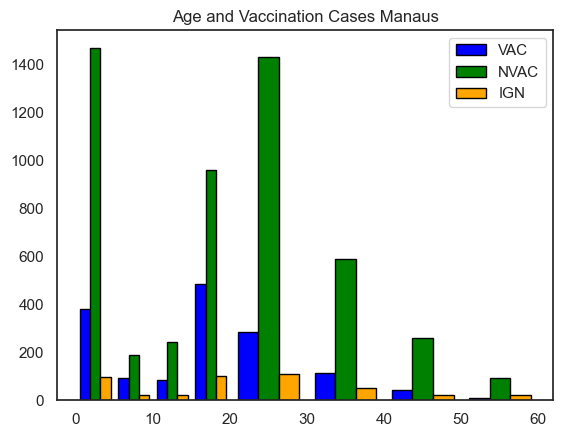

Considering ignored are vaccinated
21.5643593739851 3.252797260242177
EXCLUDING IGNORED FROM SAMPLE
[0.73802331 0.83739837 0.78680203 0.84024978 0.69548295 0.69217216
 0.65552699 0.62043796]
25.561437492907174 3.5762243697169236


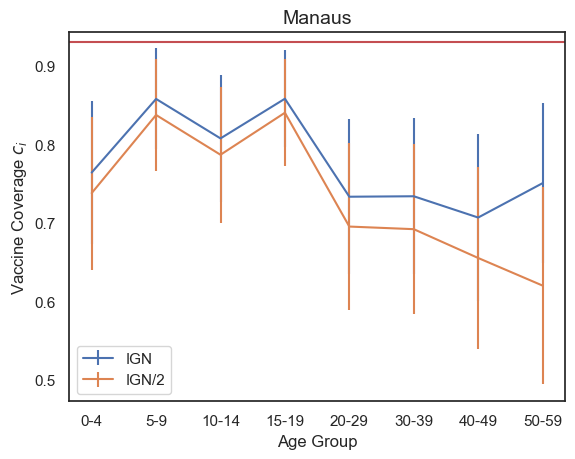

2255903


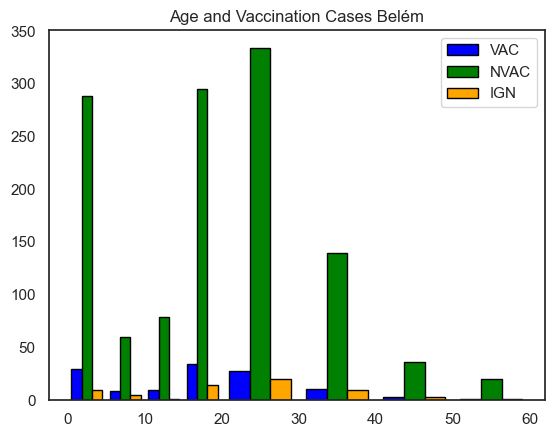

Considering ignored are vaccinated
35.699803122652156 4.413018358561202
EXCLUDING IGNORED FROM SAMPLE
[0.53386454 0.62686567 0.54441261 0.5758427  0.51820728 0.50259965
 0.54545455 0.42253521]
41.10270070206195 4.5169201390562455


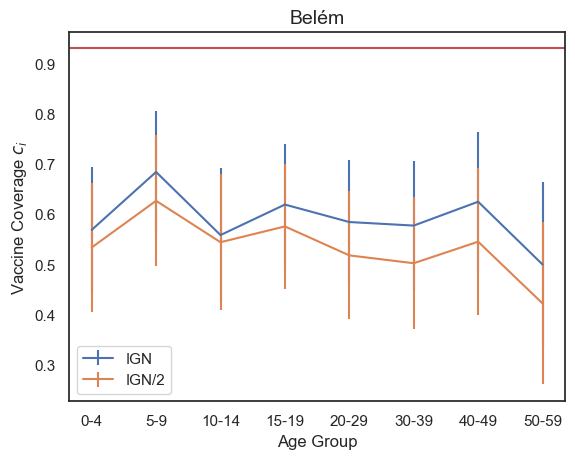

1506420


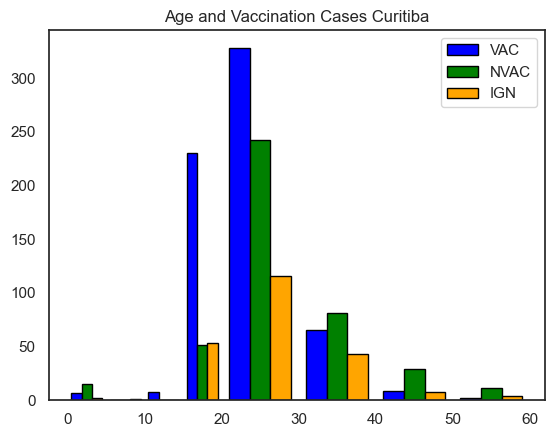

Considering ignored are vaccinated
7.268146642031216 2.096038899321626
EXCLUDING IGNORED FROM SAMPLE
[0.81395349 0.90909091 1.         0.97067171 0.9279095  0.89405685
 0.77966102 0.75471698]
10.917994377659507 3.1396236946903042


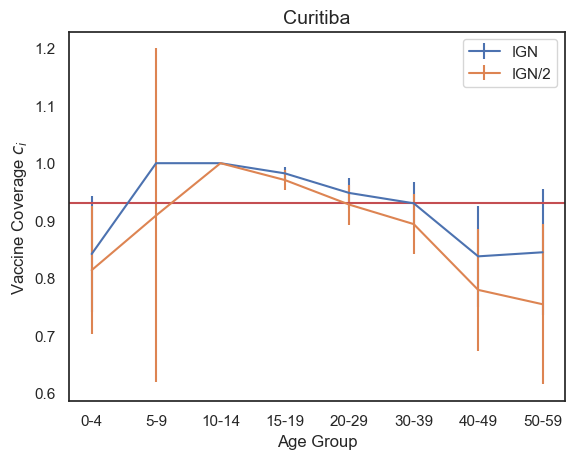

1963726


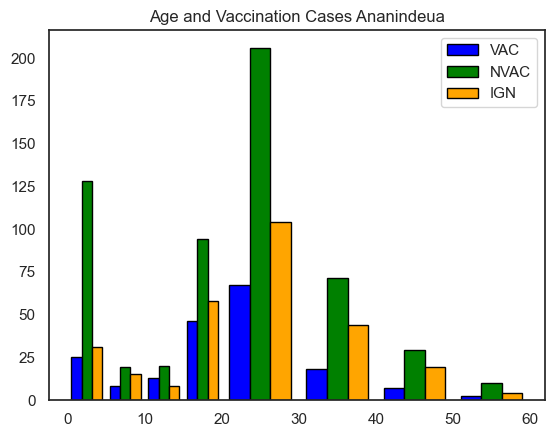

Considering ignored are vaccinated
9.67638023678609 2.0979662175782137
EXCLUDING IGNORED FROM SAMPLE
[0.73837739 0.85399449 0.87628866 0.85910653 0.8218232  0.81135903
 0.81081081 0.76923077]
16.338534007670322 3.0275854579127066


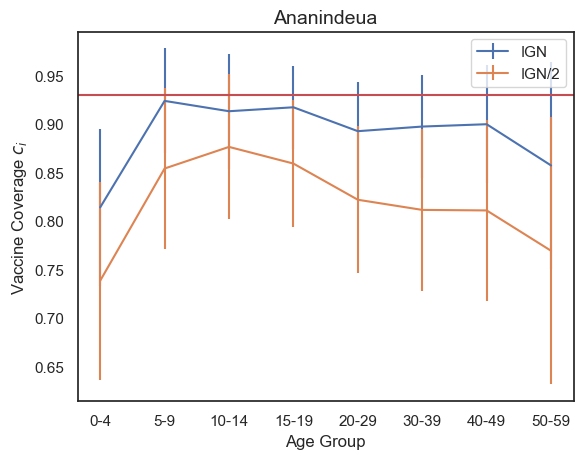

540410


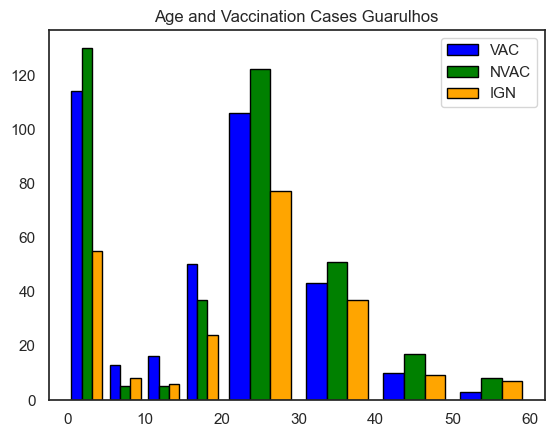

Considering ignored are vaccinated
5.216315404137587 1.478638879767933
EXCLUDING IGNORED FROM SAMPLE
[0.89984102 0.94972067 0.95959596 0.92675635 0.90003114 0.89846603
 0.87087087 0.8496732 ]
8.767877611342202 2.125138864420748


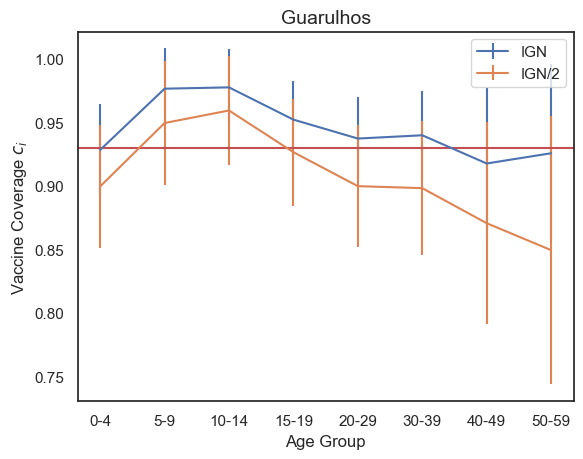

1404694


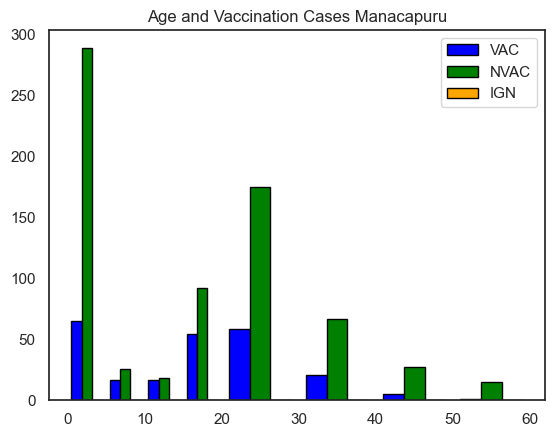

Considering ignored are vaccinated
23.296721635144145 3.5162810262759012
EXCLUDING IGNORED FROM SAMPLE
[0.69222577 0.86486486 0.8988764  0.85443038 0.76821192 0.7518797
 0.64935065 0.4       ]
23.296721635144145 3.5162810262759012


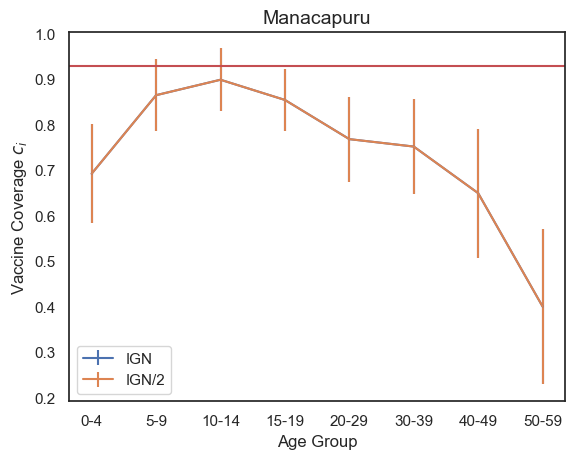

99613


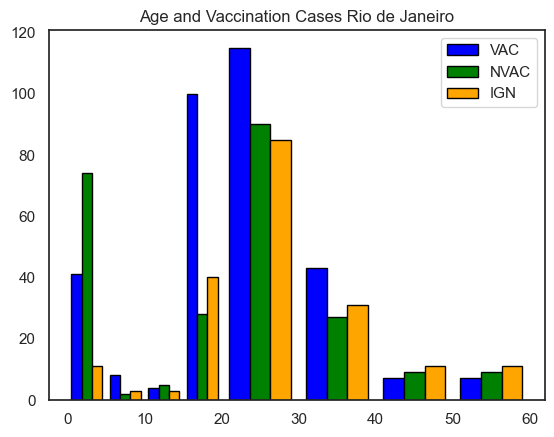

Considering ignored are vaccinated
3.801478096059257 1.207829157003484
EXCLUDING IGNORED FROM SAMPLE
[0.85399449 0.96446701 0.89430894 0.96153846 0.92240117 0.93227092
 0.89605735 0.89605735]
6.884631766609052 1.8334891659830317


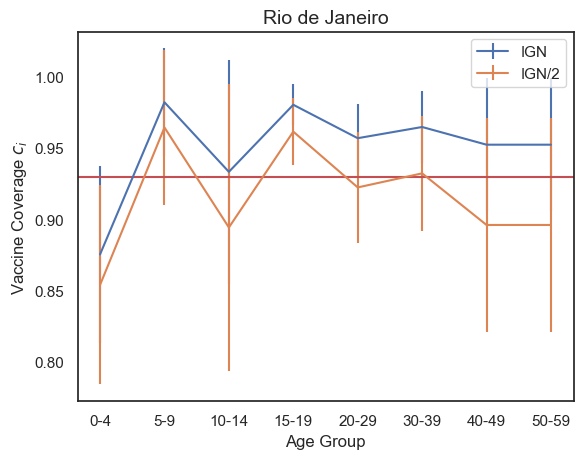

6775561


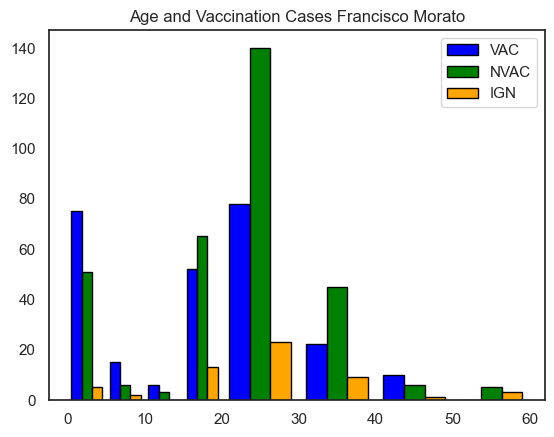

Considering ignored are vaccinated
8.14999099344686 2.319221091595247
EXCLUDING IGNORED FROM SAMPLE
[0.93542547 0.95808383 0.95238095 0.89108911 0.85523172 0.84260731
 0.94170404 0.69767442]
10.97494999236898 2.853784514171611


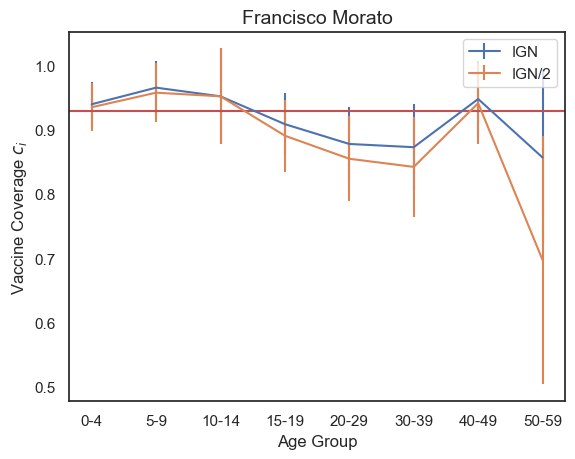

179372


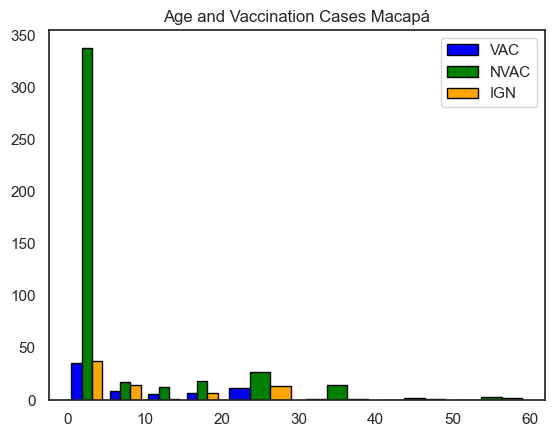

Considering ignored are vaccinated
17.839928684624983 4.767672854216096
EXCLUDING IGNORED FROM SAMPLE
[0.60011217 0.86206897 0.83870968 0.83003953 0.83932854 0.50847458
 0.66666667 0.71428571]
25.64700301501904 5.726507668799753


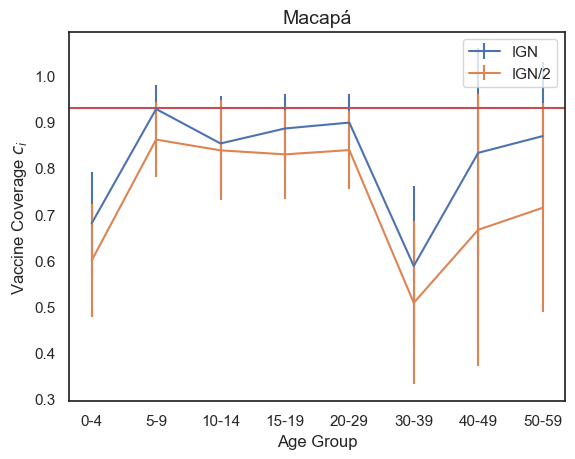

522357


In [6]:
first_10 = [355030., 130260., 150140., 410690., 150080., 351880., 130250.,
       330455., 351630., 160030.]

# data for municipalities by age
data_muns = pd.read_csv('../Data/age_groups_municipalities.csv')

# data of cases, age and their vaccination status
df_mun = pd.read_csv('../Data/analyzed/age_vaccine_municipalities.csv')
mun_path = '../Data/municipalities.csv'
mun_file = pd.read_csv(mun_path)
mun_file['codigo'] = mun_file['municipio'].astype(str).str[:6].astype(int)
mun_file = mun_file[['municipio','name','codigo']]
df_mun = df_mun.merge(mun_file, how = 'left', left_on = 'ID_MN_RESI', right_on = 'codigo')
df_pop = data_muns[['Municipio','Total']]

cov_1 = []
e_cov_1 = []
cov_2 = []
e_cov_2 = []

for mun in first_10:
    pop = df_pop[df_pop['Municipio'] == mun].iloc[0,1]
    df_tmp = df_mun[df_mun['ID_MN_RESI'] == mun]
    df_tmp = df_tmp[df_tmp['NU_IDADE_N'] <= 60]
    mun_name = df_tmp['name'].unique()[0]
    min_age = 0
    max_age = 60
    colors=['blue', 'green', 'orange']
    names=['VAC', 'NVAC', 'IGN']
    x_vac = list(df_tmp[df_tmp['CS_VACINA'] == 1]['NU_IDADE_N'])
    x_nvac = list(df_tmp[df_tmp['CS_VACINA'] == 2]['NU_IDADE_N'])
    x_ign = list(df_tmp[df_tmp['CS_VACINA'] == 9]['NU_IDADE_N'])
    bins_grouped = np.array([0,5,10,15,20,30,40,50,60])
    #bins_grouped = np.array([0,5,10,15,20,30,40])
    bins = plt.hist([x_vac, x_nvac, x_ign], color=colors, label=names, bins=bins_grouped,  edgecolor = 'black')
    plt.title('Age and Vaccination Cases '+ str(mun_name))
    plt.legend()
    plt.show()
    # CONSIDERING IGNORED ARE VACCINATED
    print('Considering ignored are vaccinated')
    vacs = bins[0][0]
    nvacs = bins[0][1]
    ign = bins[0][2]
    vacs_2 = vacs.copy()
    nvacs_2 = nvacs.copy()
    ign_2 = ign.copy()
    vacs = vacs + ign
    # first we calculate the proportion of vaccinated
    N = vacs+nvacs # sample size
    p_vacs = vacs/N # proportion of sample
    # now we calculate errors for these proportions 
    e_p_vacs = np.sqrt(p_vacs*(1 - p_vacs)/N)
    # second we propagate to calculate the vaccination coverage
    eps = 0.9 # vaccine efficacy
    e_eps_lit = 0.05 # new
    e_eps_prop = ((1 + (1-eps)*((1/p_vacs)-1))**(-2))*((1/p_vacs) - 1) # new
    c_vacs = coverage_age(p_vacs,eps)
    e_c_vacs = np.sqrt((error_coverage_age(p_vacs,eps)*e_p_vacs)**2 + (e_eps_prop*e_eps_lit)**2) # new
    # third we calculate S0 with its corresponding error
    data_sp = data_muns[data_muns['Municipio'] == mun]
    data_sp = data_sp.to_numpy()[0]
    pop_sp = data_sp[-1]
    data_sp = data_sp[2:10]
    gap_vacs = 1 - np.array(c_vacs)
    S0 = np.sum(data_sp*gap_vacs)
    e_S0 = np.sqrt(np.sum((data_sp*e_c_vacs)**2))
    print(100*S0/pop,100*e_S0/pop)
    # EXCLUDING IGNORED FROM SAMPLE
    print('EXCLUDING IGNORED FROM SAMPLE')
    vacs_2 = vacs_2 + ign_2/2
    nvacs_2 = nvacs_2 + ign_2/2
    N_2 = vacs_2 + nvacs_2 # sample size
    p_vacs_2 = vacs_2/N_2 # proportion of sample
    # now we calculate errors for these proportions 
    e_p_vacs_2 = np.sqrt(p_vacs_2*(1 - p_vacs_2)/N_2)
    # second we propagate to calculate the vaccination coverage
    eps = 0.9 # vaccine efficacy
    e_eps_lit = 0.05 # new
    e_eps_prop_2 = ((1 + (1-eps)*((1/p_vacs_2)-1))**(-2))*((1/p_vacs_2) - 1) # new
    c_vacs_2 = coverage_age(p_vacs_2,eps)
    print(c_vacs_2)
    e_c_vacs_2 = np.sqrt((error_coverage_age(p_vacs_2,eps)*e_p_vacs_2)**2 + (e_eps_prop_2*e_eps_lit)**2) # new
    # third we calculate S0 with its corresponding error
    gap_vacs_2 = 1 - np.array(c_vacs_2)
    S0_2 = np.sum(data_sp*gap_vacs_2)
    e_S0_2 = np.sqrt(np.sum((data_sp*e_c_vacs_2)**2))
    print(100*S0_2/pop,100*e_S0_2/pop)
    # NOW PLOTTING BOTH VACCINATION COVERAGES
    fig, ax = plt.subplots()
    ax.errorbar(np.arange(len(c_vacs)),c_vacs, yerr = e_c_vacs, label = 'IGN')
    ax.errorbar(np.arange(len(c_vacs_2)),c_vacs_2, yerr = e_c_vacs_2, label = 'IGN/2')
    ax.set_xticks(np.arange(len(p_vacs)))
    ax.set_xticklabels(['0-4','5-9','10-14','15-19', '20-29', '30-39','40-49','50-59'])
    ax.axhline(0.93,color = 'r')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Vaccine Coverage '+r'$c_i$')
    plt.title(mun_name, fontsize = 14)
    plt.legend()
    plt.show()
    print(pop_sp)
    cov_1.append(c_vacs)
    e_cov_1.append(e_c_vacs)
    cov_2.append(c_vacs_2)
    e_cov_2.append(e_c_vacs_2)

## Plotting for paper

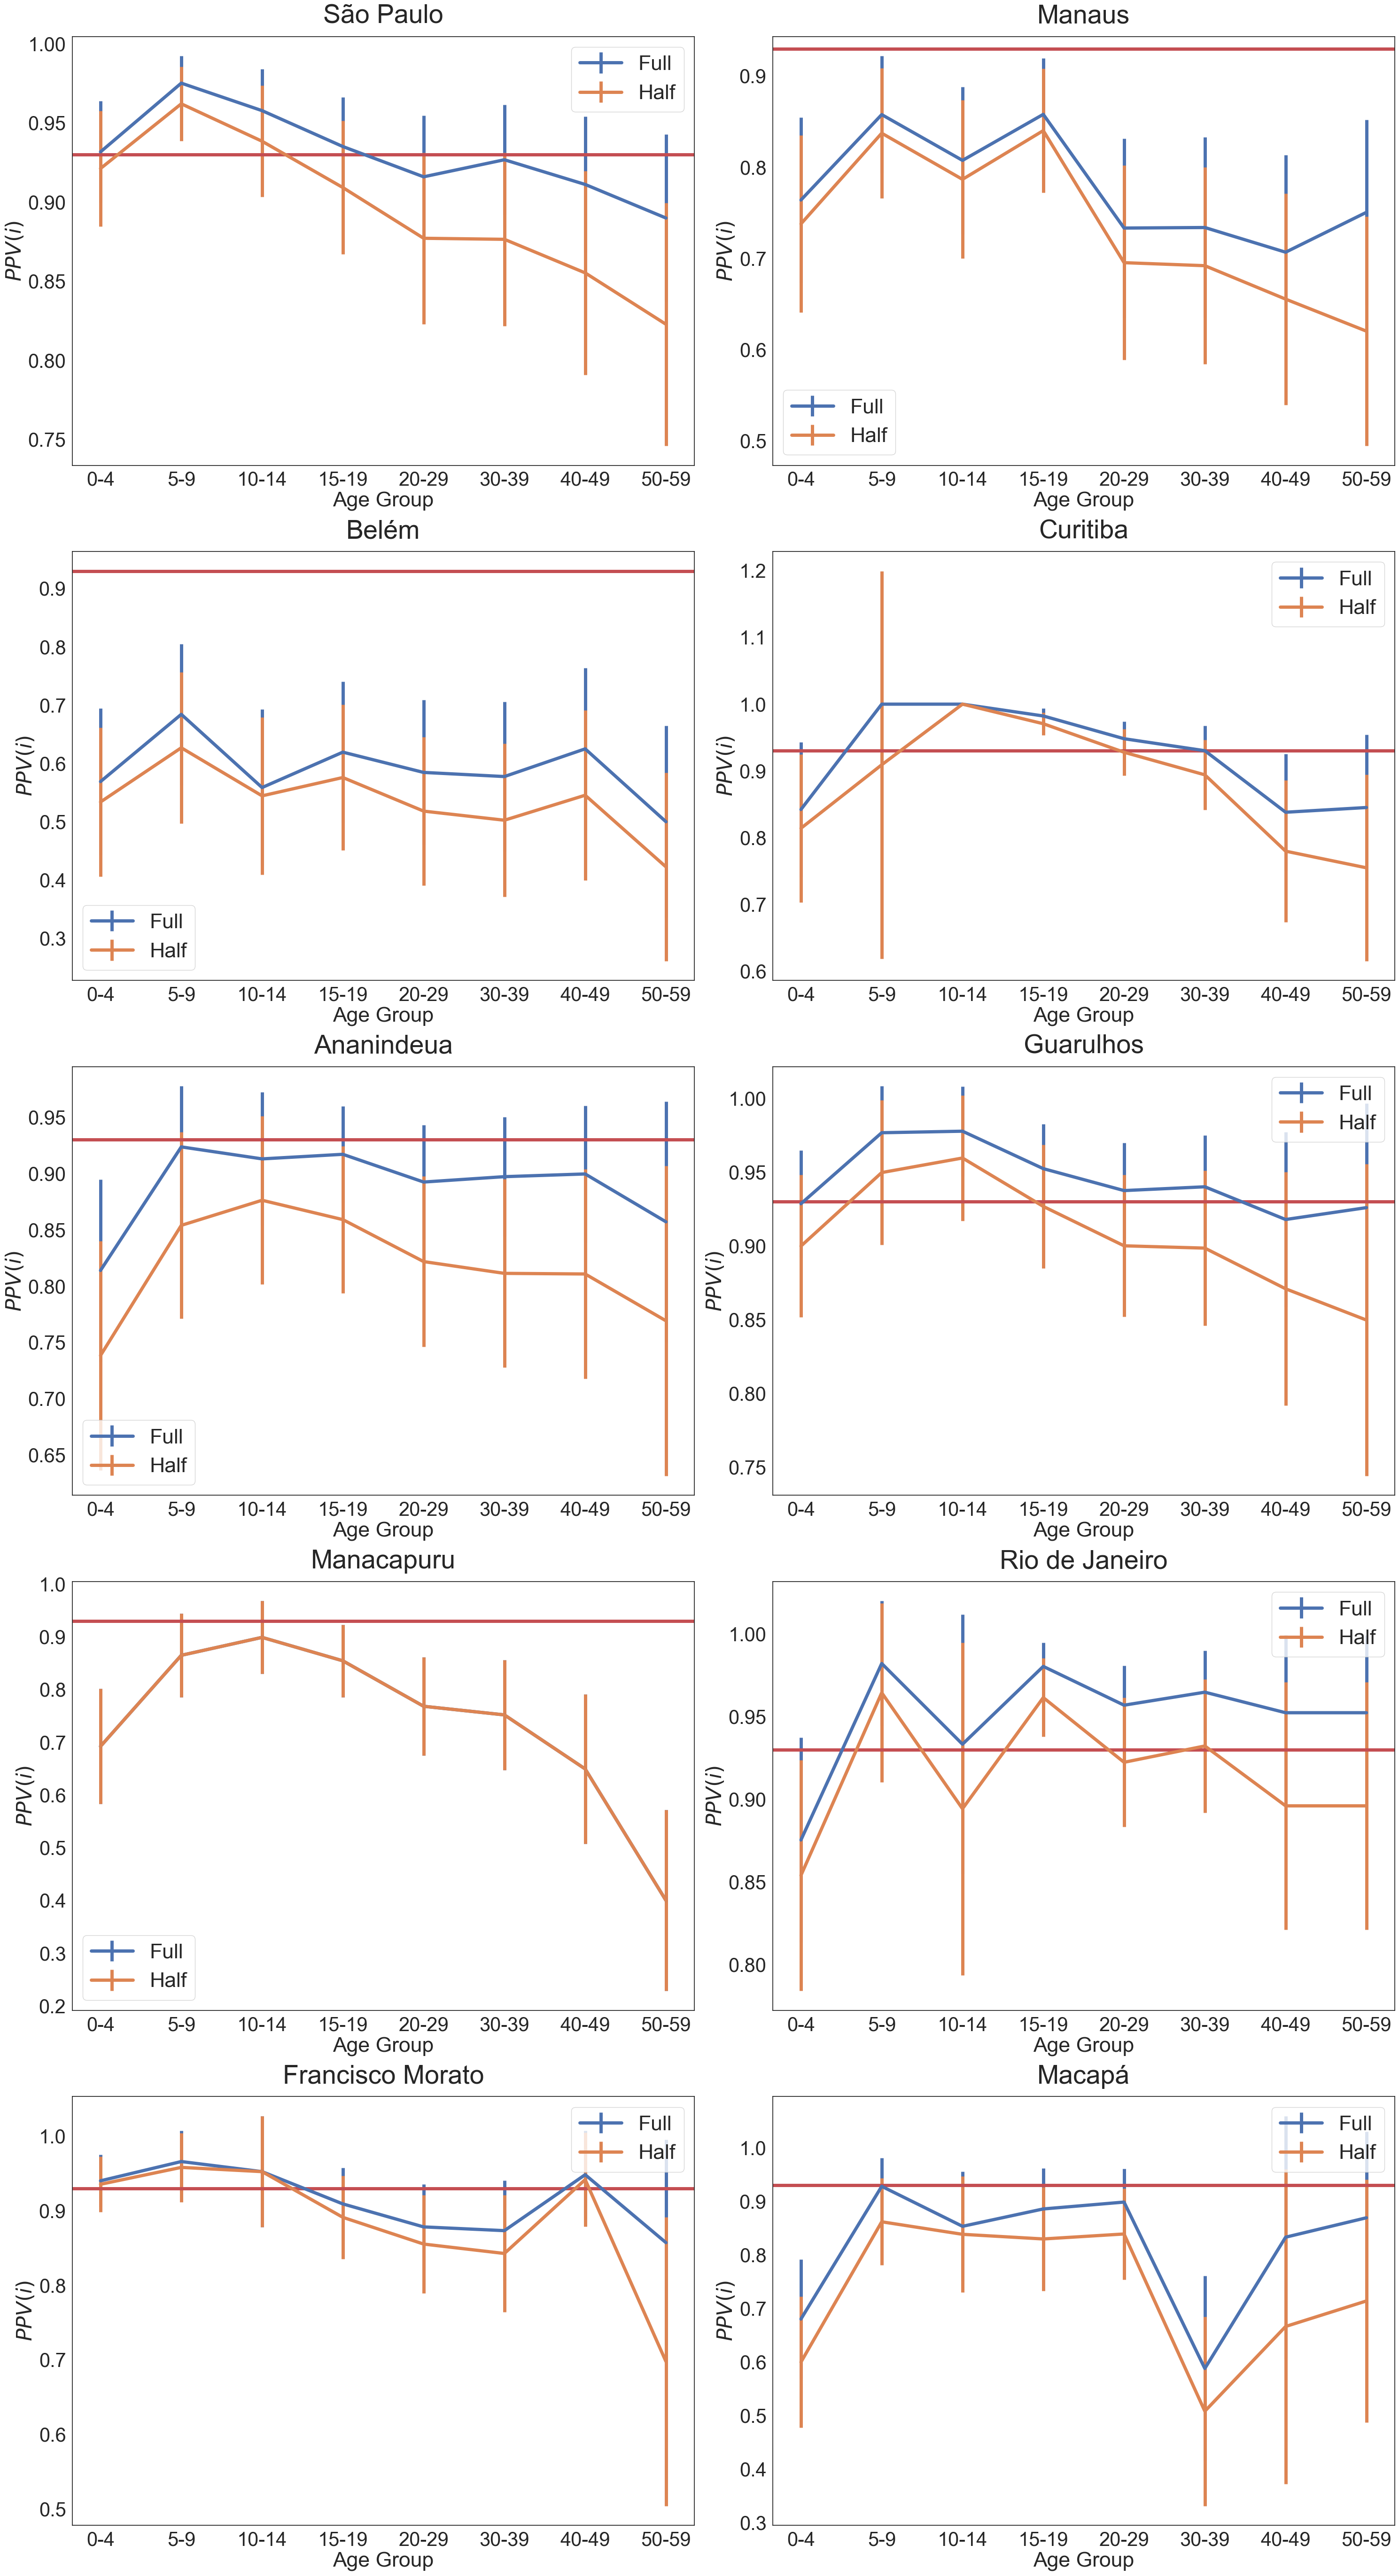

In [7]:
c = 0
fig, ax = plt.subplots(5,2,figsize = (30,55)) # 2 5 35 15
muns_name = ['São Paulo','Manaus','Belém','Curitiba','Ananindeua','Guarulhos','Manacapuru', 'Rio de Janeiro', 'Francisco Morato', 'Macapá']
mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['xtick.minor.pad'] = 10

for i in range(5): # 2
    for j in range(2): # 5
        ax[i,j].errorbar(np.arange(len(cov_1[c])),cov_1[c], yerr = e_cov_1[c], linewidth = 5, label = 'Full')
        ax[i,j].errorbar(np.arange(len(cov_2[c])),cov_2[c], yerr = e_cov_2[c], linewidth = 5, label = 'Half')
        ax[i,j].set_xticks(np.arange(len(p_vacs)))
        ax[i,j].set_xticklabels(['0-4','5-9','10-14','15-19', '20-29', '30-39','40-49','50-59'], fontsize = 20)
        ax[i,j].tick_params(axis='both', which='major', labelsize = 30)
        ax[i,j].tick_params(axis='both', which='minor', labelsize = 30)
        ax[i,j].axhline(0.93,color = 'r', linewidth = 5)
        ax[i,j].set_ylabel(r'$PPV(i)$',fontsize = 32)
        ax[i,j].set_ylabel(r'$PPV(i)$', fontsize = 32)
        ax[i,j].set_xlabel('Age Group', fontsize = 32)
        ax[i,j].set_title(muns_name[c], fontsize = 40, pad = 20)
        ax[i,j].legend(fontsize = 32)
        c = c + 1
plt.tight_layout()
plt.savefig('../Figs/subplots_coverage_plot.pdf',bbox_inches='tight')
plt.show()

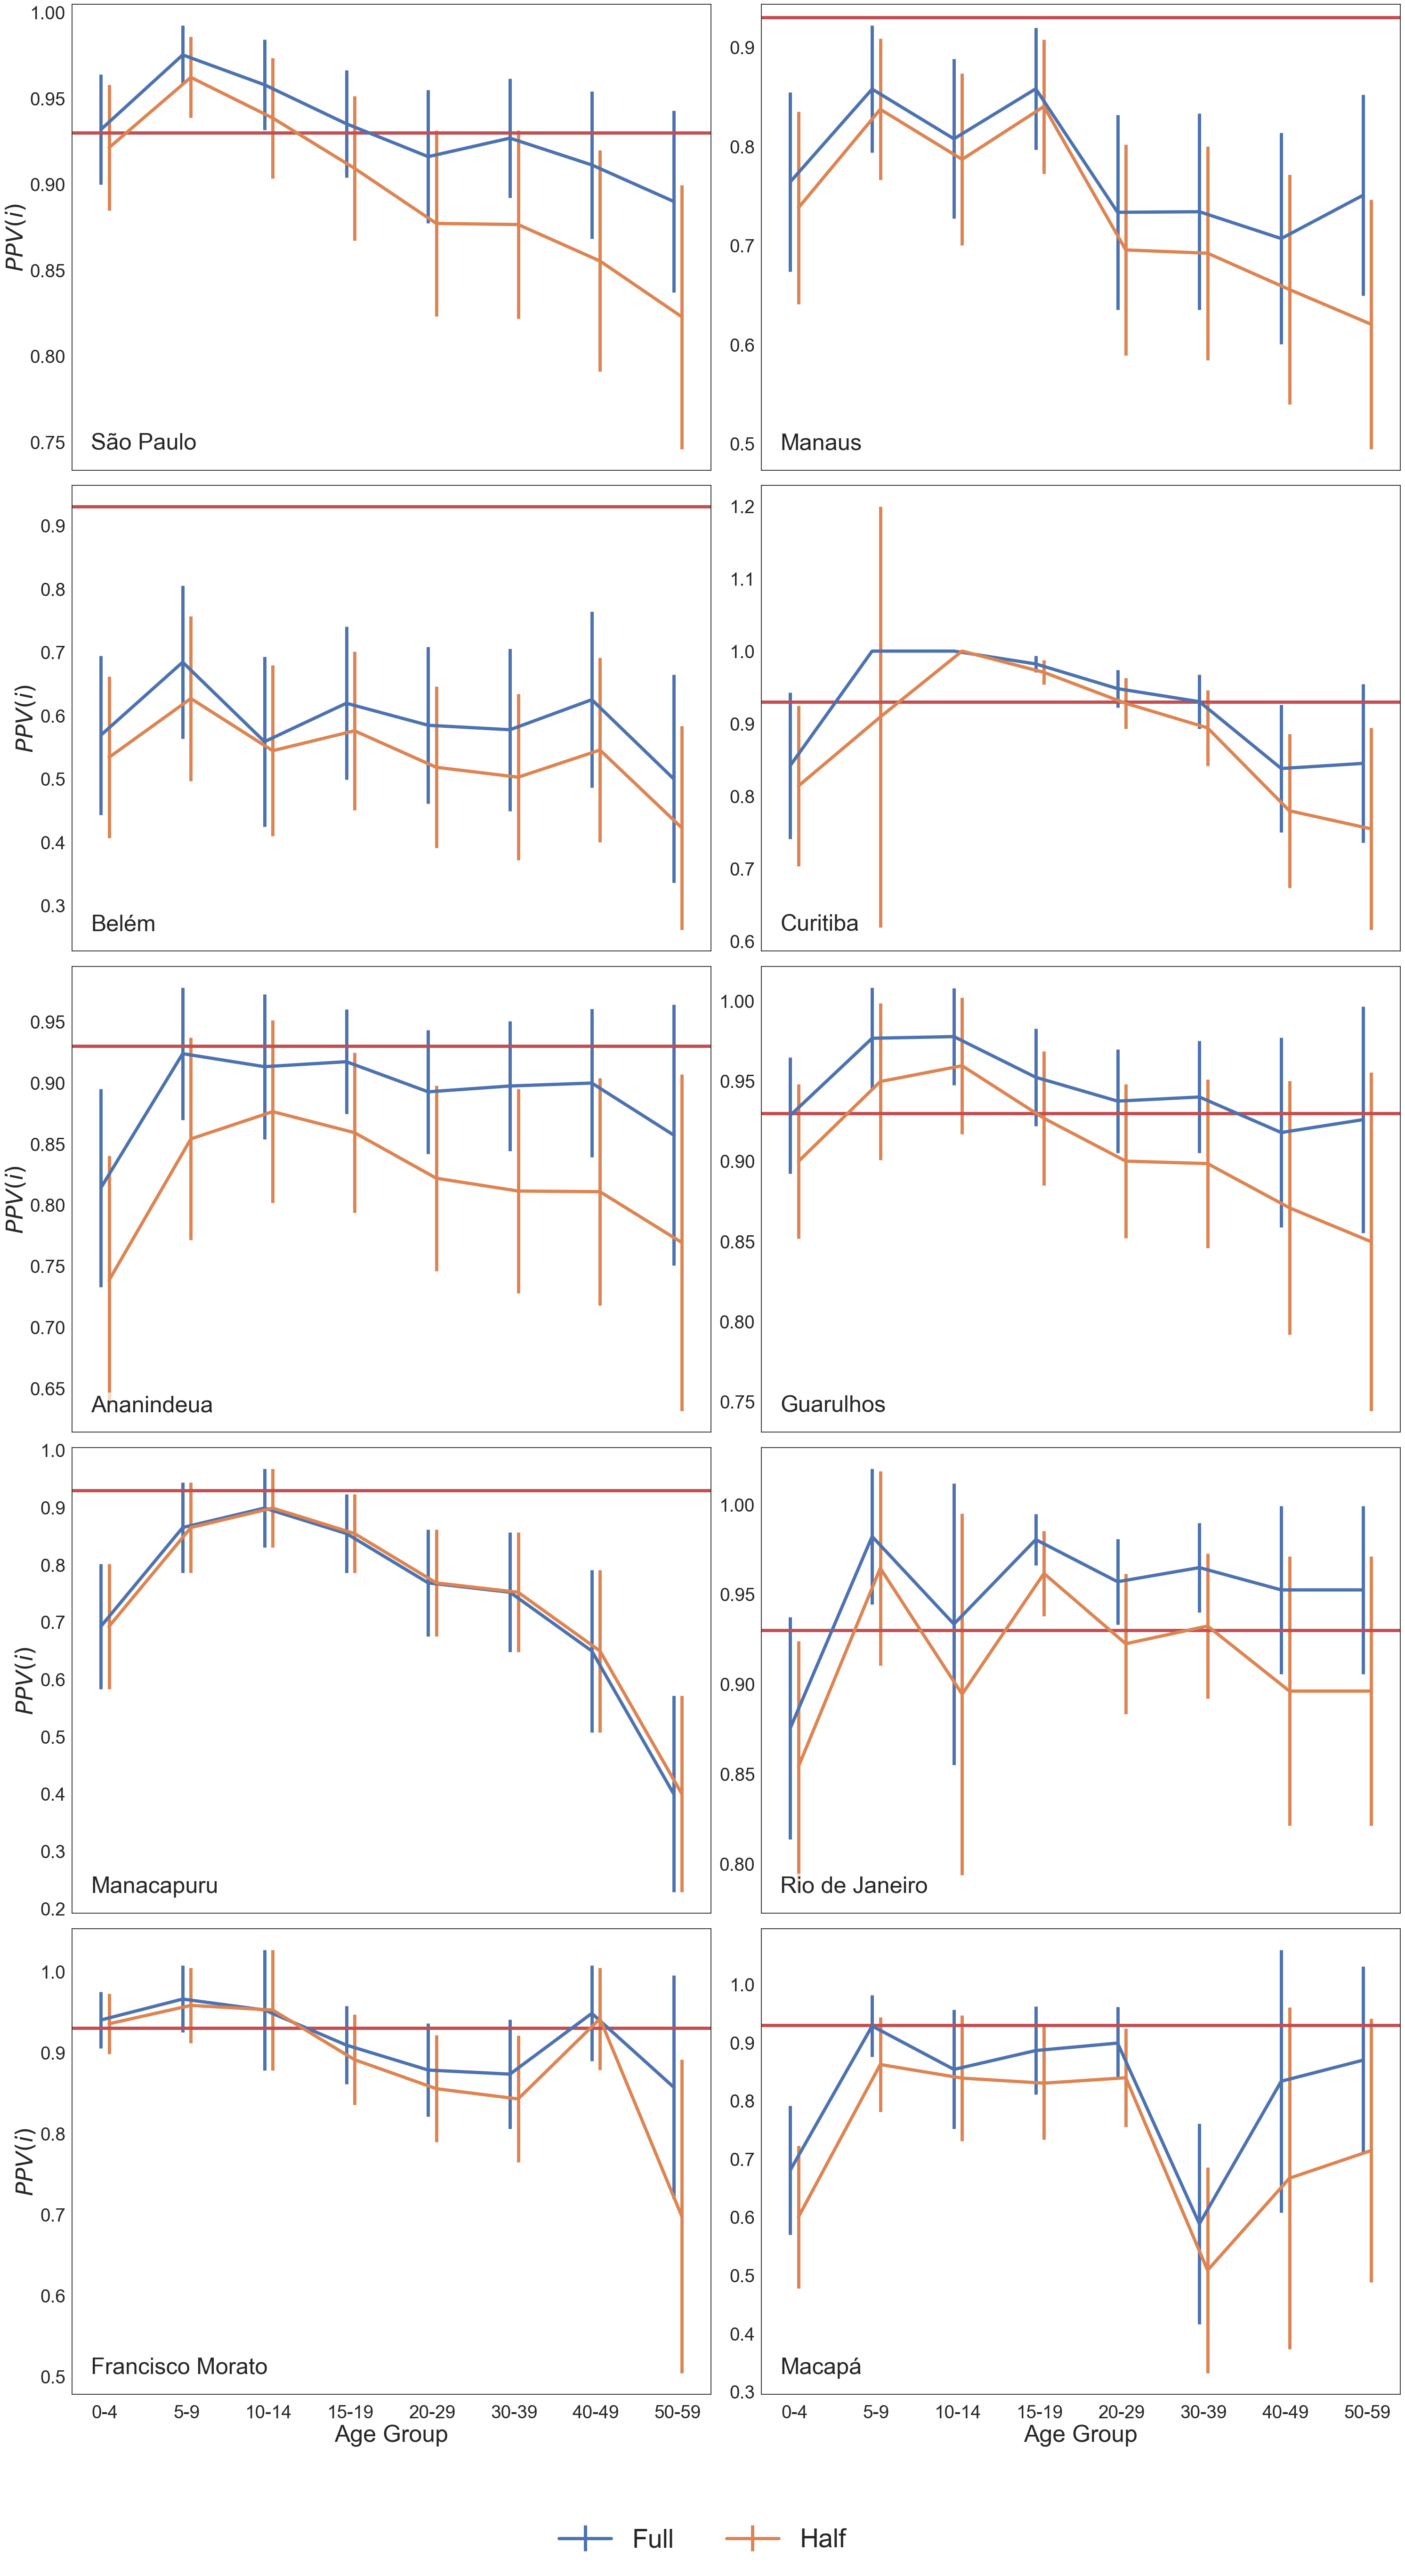

In [18]:
c = 0
fig, ax = plt.subplots(5,2,figsize=(30,55))

muns_name = ['São Paulo','Manaus','Belém','Curitiba','Ananindeua',
             'Guarulhos','Manacapuru','Rio de Janeiro',
             'Francisco Morato','Macapá']

age_labels = ['0-4','5-9','10-14','15-19','20-29','30-39','40-49','50-59']

mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['xtick.minor.pad'] = 10

delta = 0.05

for i in range(5):
    for j in range(2):

        # plots 
        line1 = ax[i,j].errorbar(np.arange(len(cov_1[c])) - delta, cov_1[c],
                                 yerr=e_cov_1[c], linewidth=5, label='Full')

        line2 = ax[i,j].errorbar(np.arange(len(cov_2[c])) + delta, cov_2[c],
                                 yerr=e_cov_2[c], linewidth=5, label='Half')

        # horizontal reference line
        ax[i,j].axhline(0.93, color='r', linewidth=5)

        # axis labels only where needed
        if i == 4:  # only bottom row
            ax[i,j].set_xticks(np.arange(len(age_labels)))
            ax[i,j].set_xticklabels(age_labels, fontsize=30)
            ax[i,j].set_xlabel('Age Group', fontsize=36)
        else:
            ax[i,j].set_xticks(np.arange(len(age_labels)))
            ax[i,j].set_xticklabels([])

        if j == 0:  # only left column
            ax[i,j].set_ylabel(r'$PPV(i)$', fontsize=36)

        # ticks
        ax[i,j].tick_params(axis='both', which='major', labelsize=28)

        # city name
        ax[i,j].text(0.03, 0.08, muns_name[c],
                     transform=ax[i,j].transAxes,
                     fontsize=35,
                     verticalalignment='top',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        c += 1

# legend below everything
fig.legend([line1, line2], ['Full', 'Half'],
           loc='lower center',
           ncol=2,
           fontsize=40,
           frameon=False)

plt.tight_layout(rect=[0,0.05,1,1])  # leave space for legend

plt.savefig('../Figs/subplots_coverage_plot.pdf', bbox_inches='tight')
plt.show()